## Import libraries

In [214]:
import pytesseract
import cv2
import numpy as np
import PIL
from pdf2image import convert_from_path
import os
from pathlib import Path
import matplotlib.pyplot as plt

Detect and crop the table by 

In [3]:
import cv2
import os

image = cv2.imread(r"D:\Programming\Projects\Learning python librairies\OCR\Data before preprocessing\page_10.png", cv2.IMREAD_GRAYSCALE)

# Detect horizontal lines
horizontal_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (40, 1)
)

horizontal = cv2.morphologyEx(
    image,
    cv2.MORPH_OPEN,
    horizontal_kernel
)

# Detect vertical lines
vertical_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (1, 40)
)

vertical = cv2.morphologyEx(
    image,
    cv2.MORPH_OPEN,
    vertical_kernel
)

# Combine horizontal + vertical lines
table_structure = cv2.add(horizontal, vertical)

# Find contours
contours, _ = cv2.findContours(
    table_structure,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

os.makedirs("cropped_tables", exist_ok=True)

table_number = 0

for contour in contours:

    x, y, w, h = cv2.boundingRect(contour)

    # Ignore very small regions
    if w > 100 and h > 50:

        table_crop = image[y:y+h, x:x+w]

        table_number += 1

        cv2.imwrite(
            f"cropped_tables/table_{table_number}.png",
            table_crop
        )

print("Tables detected:", table_number)

Tables detected: 3


## output images

In [215]:
out_put_images = "Sample Output Images"
os.makedirs(out_put_images, exist_ok=True)

In [216]:
os.cpu_count()

12

In [217]:
images = convert_from_path(
    "sample.pdf",
    dpi=1000,
    poppler_path=r"D:\Programming\Projects\Learning python librairies\OCR\Release-26.02.0-0\poppler-26.02.0\Library\bin",
    thread_count=os.cpu_count()
)

In [218]:
for i, image in enumerate(images):
    image_path = os.path.join(out_put_images, f"page_{i + 1}.png")
    image.save(image_path, "PNG")

    # Read the image using OpenCV
    img = cv2.imread(image_path)

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [219]:
folder_path = Path(out_put_images)
img = [i for i in folder_path.iterdir() if i.suffix in ['.png', '.jpg', '.jpeg']]

In [220]:
img

[WindowsPath('Sample Output Images/page_1.png'),
 WindowsPath('Sample Output Images/page_10.png'),
 WindowsPath('Sample Output Images/page_11.png'),
 WindowsPath('Sample Output Images/page_12.png'),
 WindowsPath('Sample Output Images/page_13.png'),
 WindowsPath('Sample Output Images/page_14.png'),
 WindowsPath('Sample Output Images/page_15.png'),
 WindowsPath('Sample Output Images/page_16.png'),
 WindowsPath('Sample Output Images/page_17.png'),
 WindowsPath('Sample Output Images/page_18.png'),
 WindowsPath('Sample Output Images/page_19.png'),
 WindowsPath('Sample Output Images/page_2.png'),
 WindowsPath('Sample Output Images/page_20.png'),
 WindowsPath('Sample Output Images/page_21.png'),
 WindowsPath('Sample Output Images/page_22.png'),
 WindowsPath('Sample Output Images/page_23.png'),
 WindowsPath('Sample Output Images/page_24.png'),
 WindowsPath('Sample Output Images/page_3.png'),
 WindowsPath('Sample Output Images/page_4.png'),
 WindowsPath('Sample Output Images/page_5.png'),
 Wind

In [221]:
# # Load images
# images = [np.array(PIL.Image.open(str(i))) for i in img]

# # Find maximum dimensions
# max_height = max(image.shape[0] for image in images)
# max_width = max(image.shape[1] for image in images)

# # Pad all images to the same size
# padded_images = []

# for image in images:
#     height, width = image.shape[:2]

#     # For grayscale images
#     padded = np.zeros((max_height, max_width), dtype=image.dtype)

#     padded[:height, :width] = image

#     padded_images.append(padded)

# # Convert to NumPy array
# img = np.array(padded_images)

# print(img.shape)

In [222]:
img = np.array([PIL.Image.open(str(i)).resize((1000, 1700)) for i in img])

In [223]:
img = 255-img

In [224]:
img

array([[[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],

        ...,

        [[44, 45, 45],
         [44, 45, 45],
         [44, 45, 45],
         ...,
         [44, 45, 45],
         [44, 45, 45],
         [40, 41, 41]],

        [[44, 45, 45],
         [44, 45, 45],
         [44, 45, 45],
         ...,
         [44, 45, 45],
         [44, 45, 45],
         [40, 41, 41]],

        [[42, 43, 43],
         [42, 43, 43],
         [42, 43, 43],
         ...,
         [42, 43, 43],
         [42, 43, 43],
         [38, 39, 39]]],


       [[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0, 

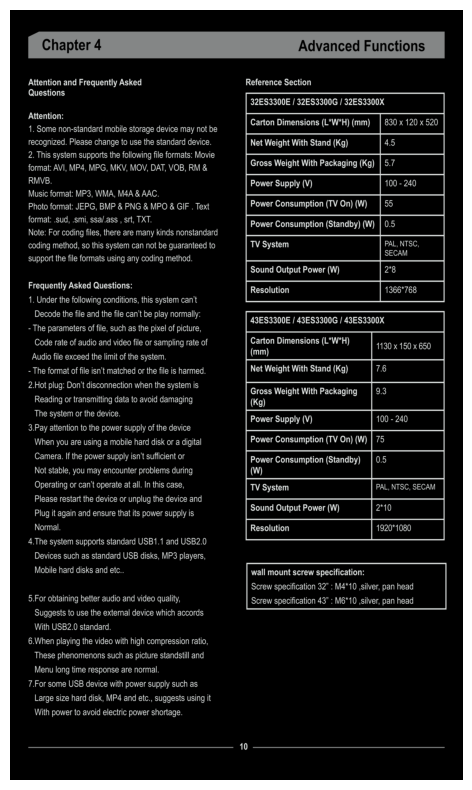

In [225]:
plt.figure(figsize=(10, 10))
plt.imshow(img[1], cmap='gray')
plt.grid(False)
plt.axis('off')
plt.show()

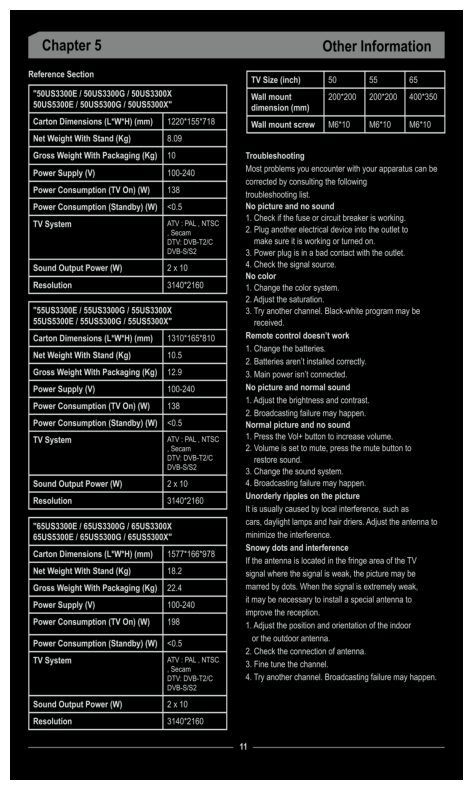

In [226]:
plt.figure(figsize=(10, 10))
plt.imshow(img[2], cmap='gray')

plt.grid(False)
plt.axis('off')
plt.show()

In [227]:
binimg = []

for i in range(len(img)):

    # Convert BGR → grayscale
    gray = cv2.cvtColor(img[i], cv2.COLOR_BGR2GRAY)

    # Apply Otsu thresholding
    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    binimg.append(binary)

In [228]:
img = np.array(binimg)

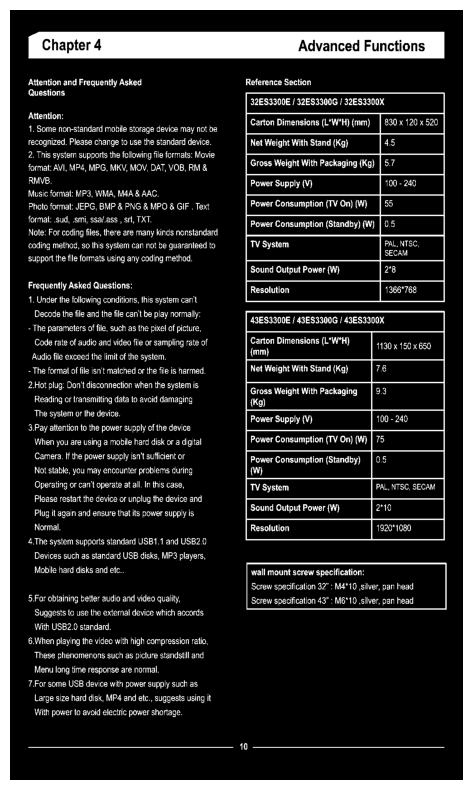

In [229]:
plt.figure(figsize=(10, 10))

plt.imshow(binimg[1], cmap='gray')
plt.grid(False)
plt.axis('off')

plt.savefig("Sample Output.png")
plt.show()

In [231]:
def noise_removal(image):
    kernel = np.ones((1, 1), np.uint8)
    # denoised = cv2.dilate(image, kernel, iterations=1)
    denoised = cv2.erode(image, kernel, iterations=1)
    denoised = cv2.morphologyEx(denoised, cv2.MORPH_CLOSE, kernel)
    denoised = cv2.medianBlur(denoised, 3)
    return denoised
denoised_images = [noise_removal(image) for image in img]

In [232]:
img = np.array(denoised_images)

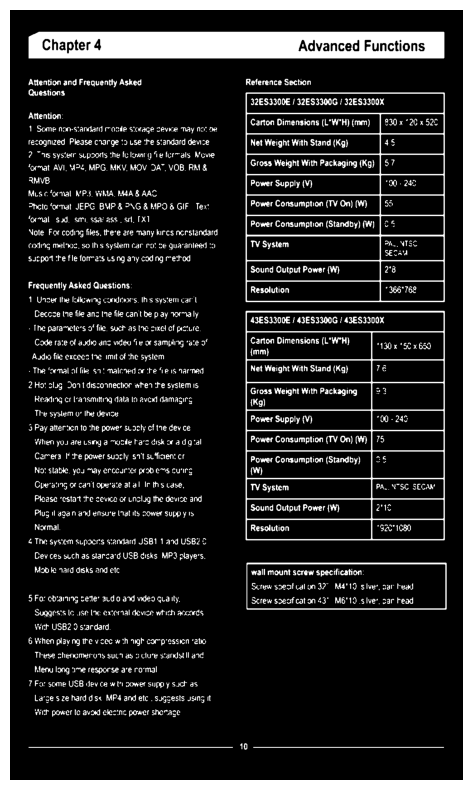

In [233]:
plt.figure(figsize=(10, 10))

plt.imshow(img[1], cmap='gray')
plt.grid(False)
plt.axis('off')

plt.savefig("Sample Output.png")
plt.show()

In [234]:
import cv2
import numpy as np

def get_skew_angle(image):
    # Get coordinates of foreground pixels
    coords = np.column_stack(np.where(binary > 0))

    # Find the rotated rectangle
    angle = cv2.minAreaRect(coords)[-1]

    # Convert OpenCV angle to normal skew angle
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    return angle
get_skew_angle(img[1])

-90.0

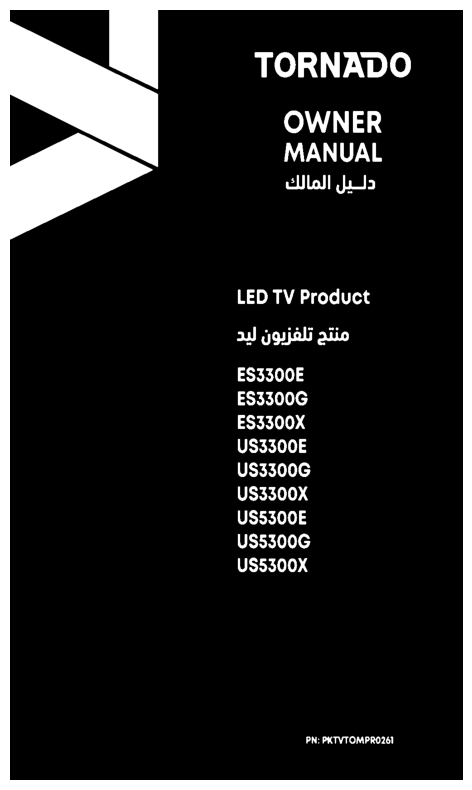

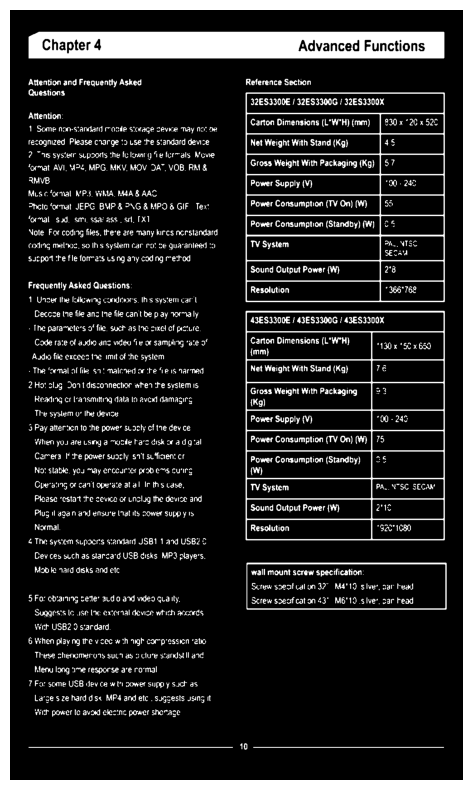

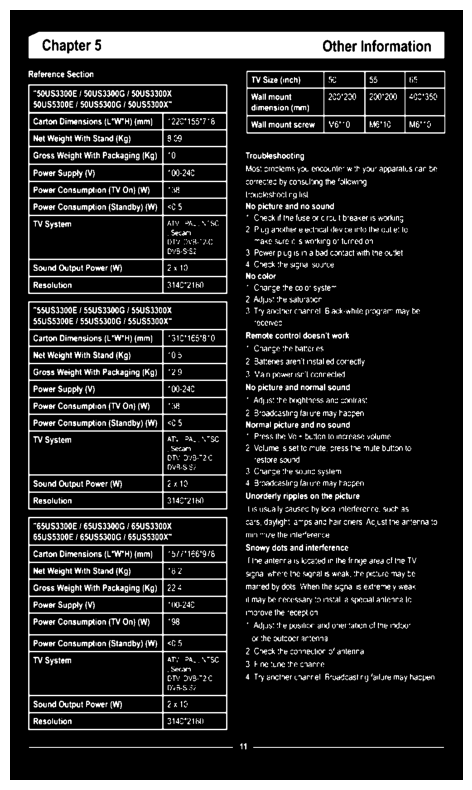

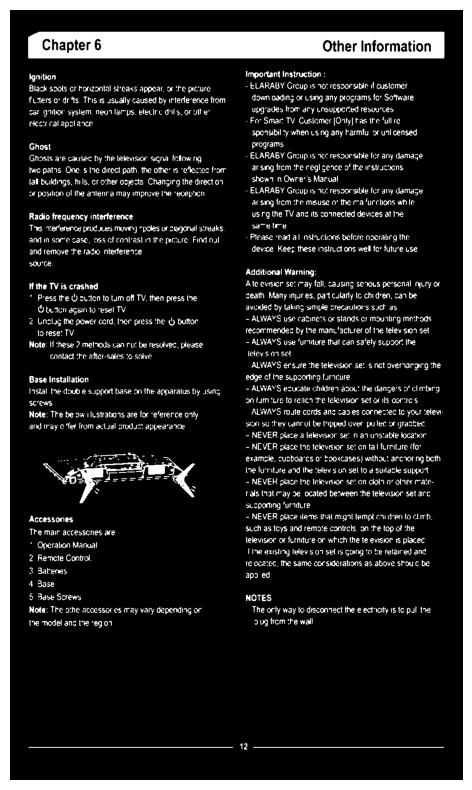

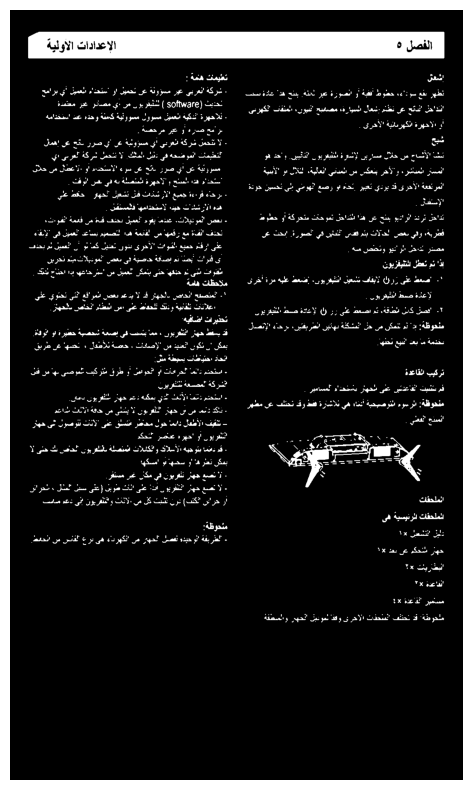

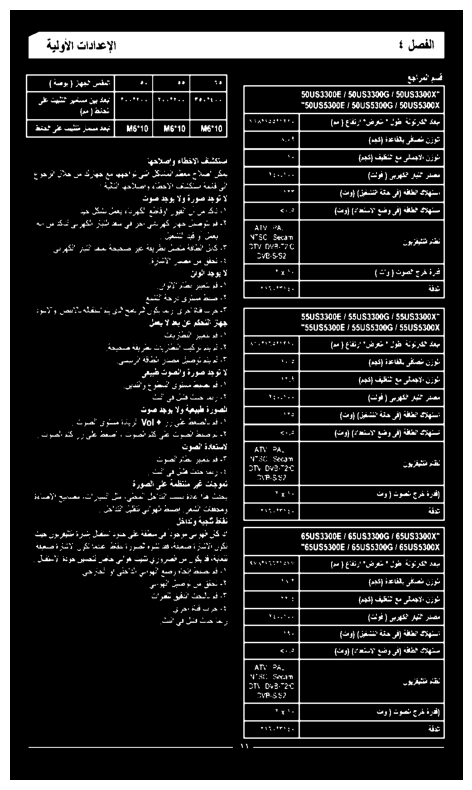

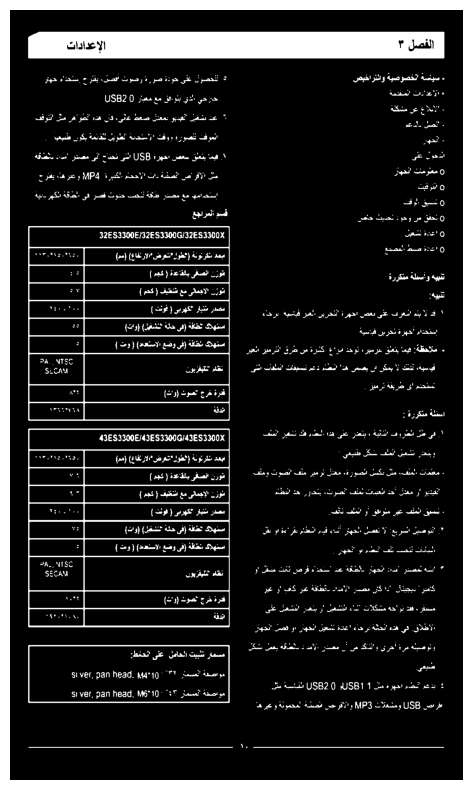

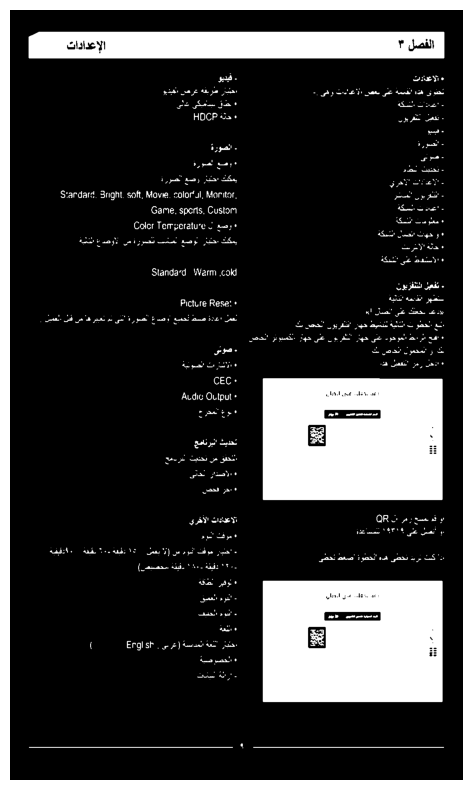

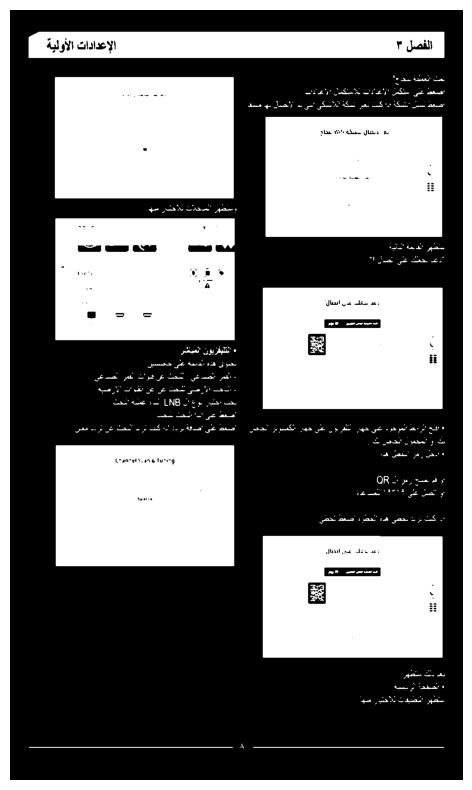

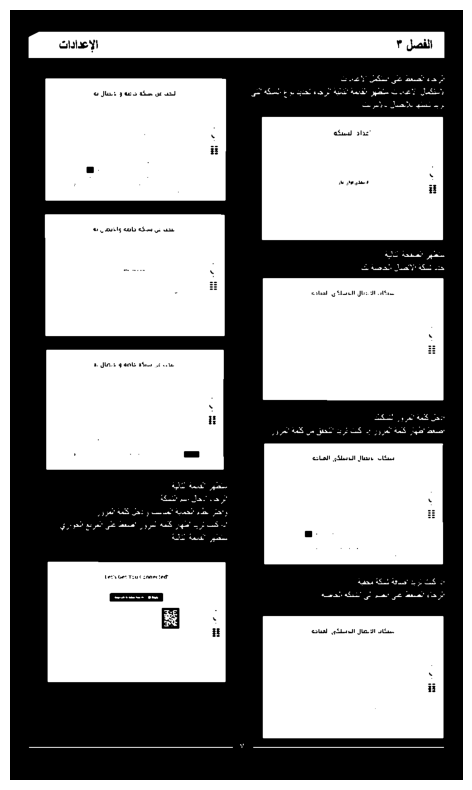

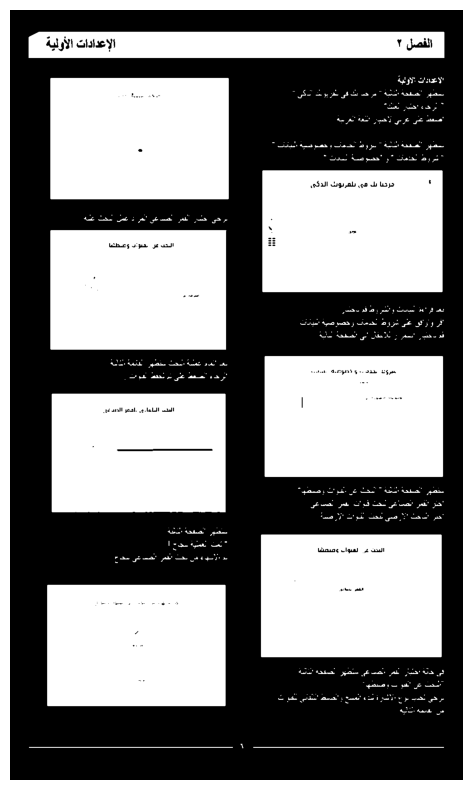

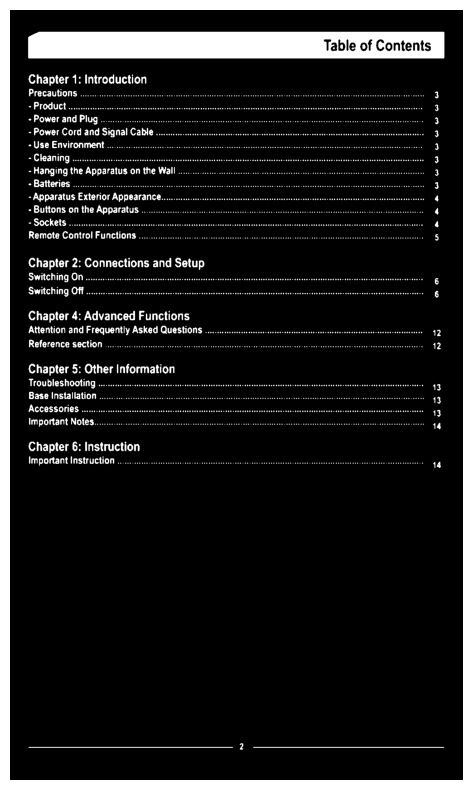

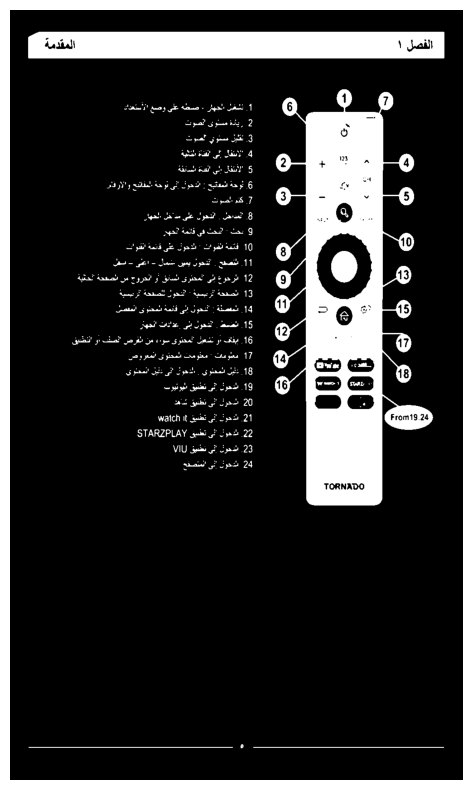

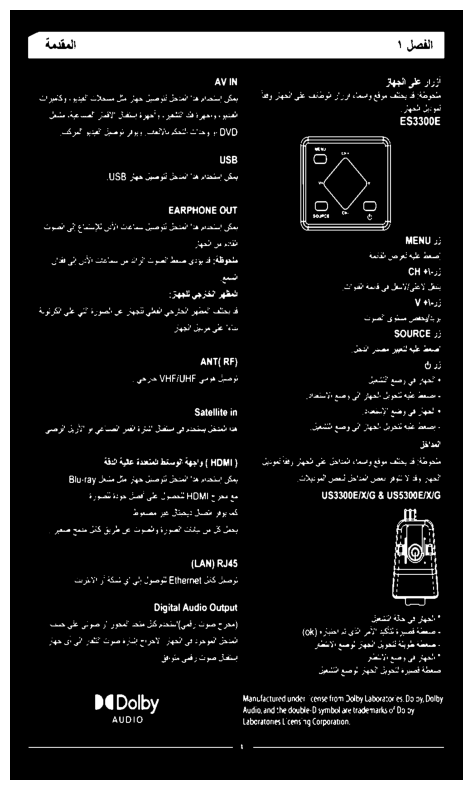

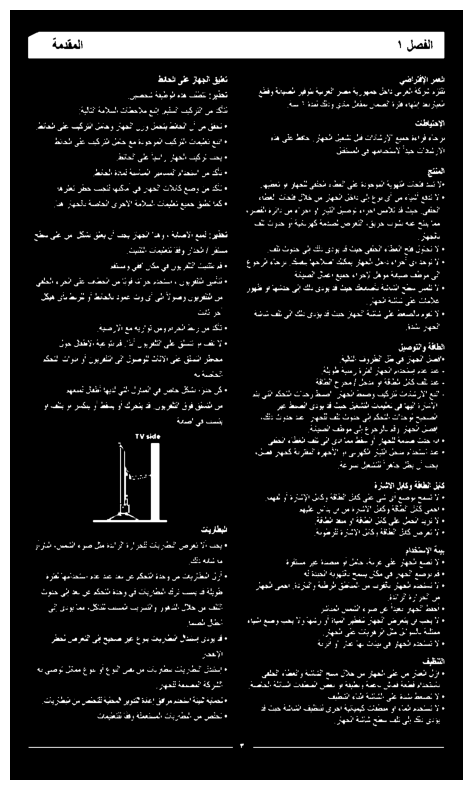

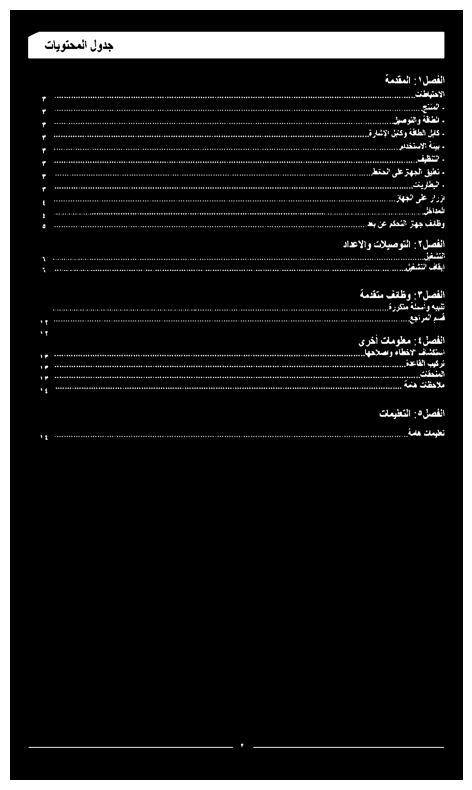

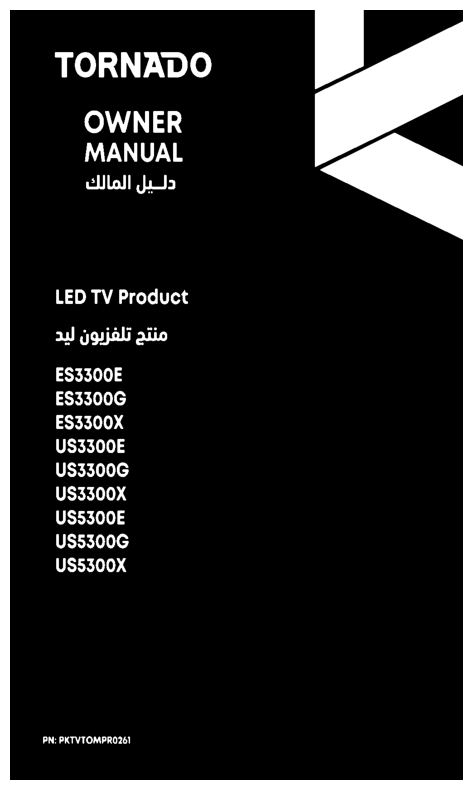

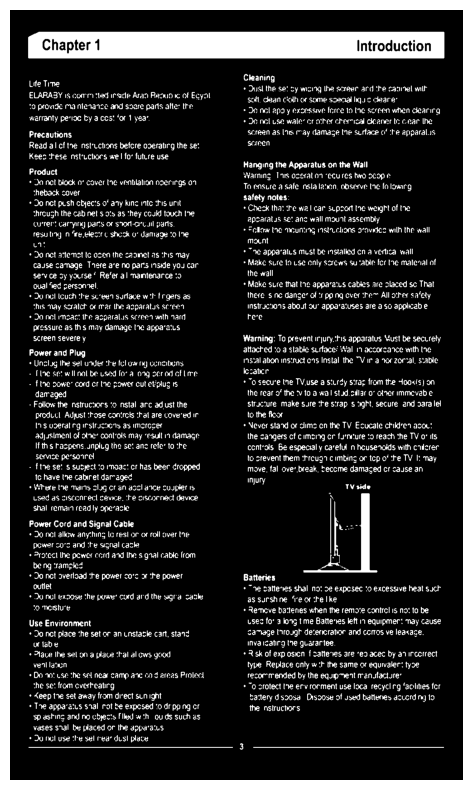

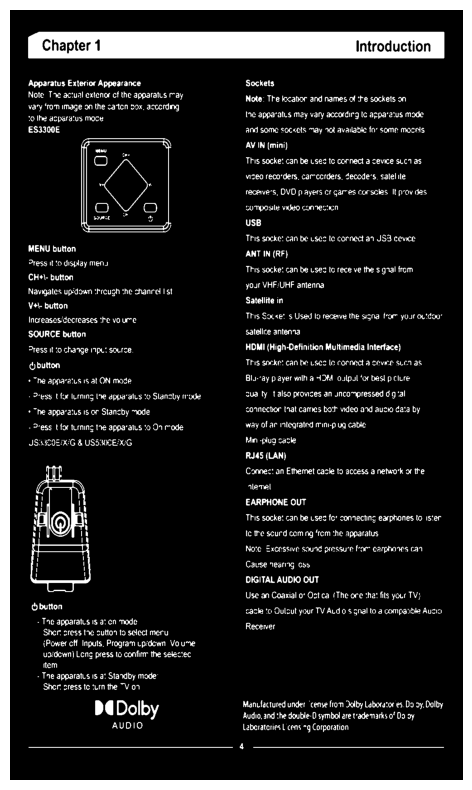

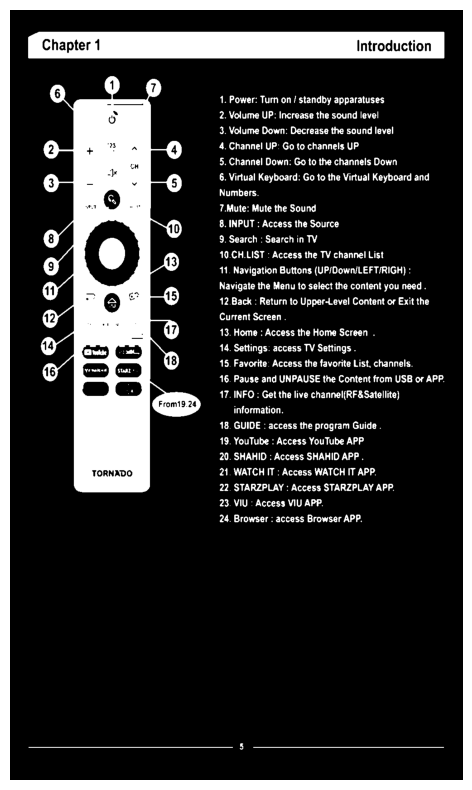

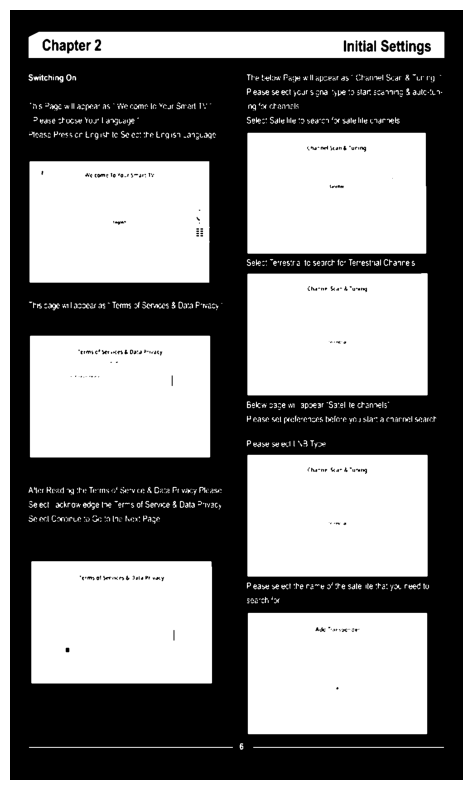

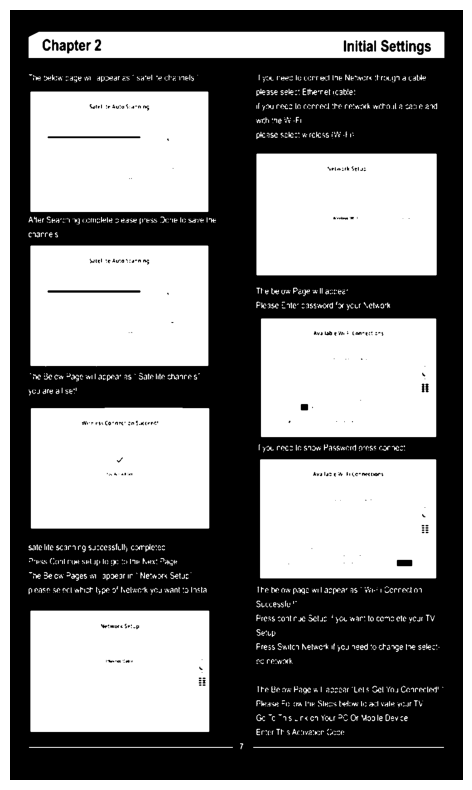

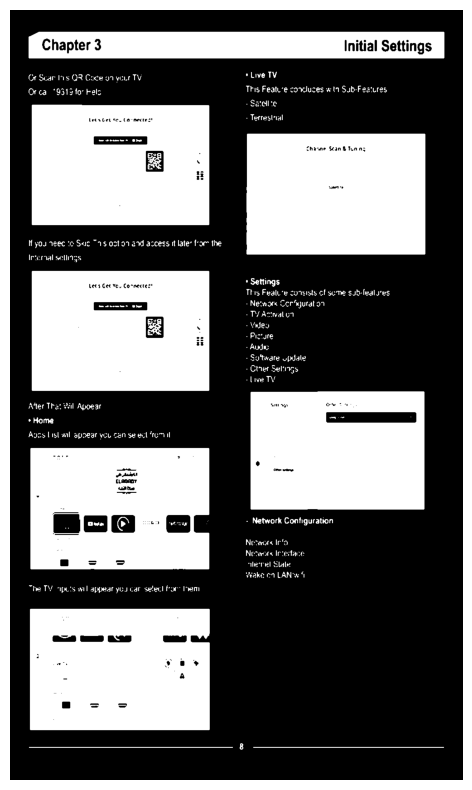

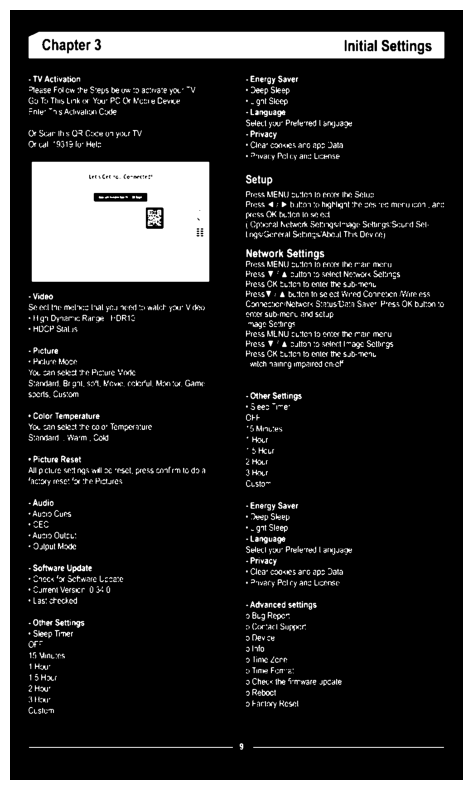

In [235]:
for _, i in enumerate(img):

    plt.figure(figsize=(10, 10))

    plt.imshow(i, cmap='gray')
    plt.grid(False)
    plt.axis('off')

    plt.savefig(
        rf"Preprocessed image\Sample Output_{_}.png",
        bbox_inches='tight',
        pad_inches=0
    )

    plt.show()
    plt.close()

In [236]:
open("text.txt", 'w')

<_io.TextIOWrapper name='text.txt' mode='w' encoding='utf-8'>

In [237]:
for i in os.listdir("Preprocessed image"):
  img = PIL.Image.open(f"Preprocessed image\{i}")
  text = pytesseract.image_to_string(img, lang='eng+ara')
  open("text.txt", 'a').write(text)

<string>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
<string>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
C:\Users\elkha\AppData\Local\Temp\ipykernel_2880\1941045601.py:2: SyntaxWarning: invalid escape sequence '\{'
  img = PIL.Image.open(f"Preprocessed image\{i}")
